# Homework 3

## FINM 35700 - Spring 2026

### UChicago Financial Mathematics

### Due Date: 2026-04-14

* Yiyang Yu
* yiyangyu@uchicago.edu

This homework relies on:

- the corporate and government bonds symbology file `bond_symbology`, 
- the "on-the-run" treasuries data file `govt_on_the_run`,
- the bond market data file `bond_market_prices_eod`, containing EOD price data as of 2026-03-23.
- the corporate bonds call schedule file `call_schedules`.


-----------------------------------------------------------
# Problem 1: Different types of bond yields and durations (fixed income recap)

### A. Continuously compounded (exponential) yields
In Lecture 1 we introduced the continuously compounded (exponential) yield $y$, used to discount bonds with arbitrary/generic cashflows 

\begin{align}
\{c_i ,T_i\}_{i=1..n}
\end{align} 

via the valuation formula

\begin{align}
B(y)=\sum_{i=1}^{n}c_{i}\cdot e^{-T_{i}\cdot y}
\end{align}

We then defined the bond duration $D$ (also called Macaulay duration) as the log-sensitivity of the bond price with respect to the exponential yield $y$:

\begin{align}
\frac{\partial B}{\partial y} = -B \cdot D
\end{align}

and showed that $D$ can be expressed as a weighted sum of time to maturities $T_i$

\begin{align}
D=\frac{\sum_{i=1}^{n}T_i \cdot c_{i}\cdot e^{-T_{i}\cdot y}}{\sum_{i=1}^{n}c_{i}\cdot e^{-T_{i}\cdot y}} = \sum_{i=1}^{n}T_i \cdot w_i
\end{align}

### B. Discretely compounded yields
For bonds with n regular coupon payment (coupon frequency = n), it is natural to define the discretely compounded yields $y_n$ (corresponding to the coupon frequency n):


\begin{align}
\left(1+\frac{y_{n}}{n}\right)^n=e^y
\end{align}

The most common cases in US fixed income markets are:

1. Semi-annual coupon frequency (e.g fixed rate USD bonds): the semi-annual yield $y_{sa} = y_2$ satisfies the formula

\begin{align}
\left(1+\frac{y_{sa}}{2}\right)^2=e^y
\end{align}

2. Quarterly coupon frequency (e.g floating rate USD bonds): the quarterly yield $y_{qt} = y_4$ satisfies the formula

\begin{align}
\left(1+\frac{y_{qt}}{4}\right)^4=e^y
\end{align}


3. Monthly coupon frequency (e.g USD loans): the monthly yield $y_{mo} = y_{12}$ satisfies the formula

\begin{align}
\left(1+\frac{y_{mo}}{12}\right)^{12}=e^y
\end{align}

As a general rule, discretely compunded yields are descreasing in the coupon frequency n:

\begin{align}
y_{sa} \geq y_{qt} \geq y_{mo} \geq y_{\infty} = y
\end{align}

### C. Modified duration
For a bond with n regular coupon payments, the modified duration $D_{mod}$ is defined as the log-sensitivity of the bond price with respect to the discretely compounded yield $y_n$:

\begin{align}
\frac{\partial B}{\partial y_{n}} = -B \cdot D_{mod}
\end{align}


In practice, when fixed income market participants talk about yields, DV01s and durations, they imply the type based on the cashflow frequency of the underlying instrument.

## To do:

### a. For fixed rate semi-annual USD bonds (frequency = 2), show that

\begin{align}
D_{mod} = D \cdot \left(1+\frac{y_{sa}}{2} \right)^{-1}
\end{align}


\begin{aligned}
& \frac{\partial B}{\partial y_{sa}} = \frac{\partial B}{\partial y} \cdot \frac{\partial y}{\partial y_{sa}} \\
& \left(1+\frac{y_{sa}}{2}\right)^2=e^y \\
& 2 log{(1+\frac{y_{sa}}{2})} = y \\
& \frac{\partial y}{\partial y_{sa}} = \frac{1}{1+y_{sa}/2} \\
& \frac{\partial B}{\partial y_{sa}} = -B \cdot D \cdot \frac{1}{1+y_{sa}/2} = -B \cdot D_{mod}
\end{aligned}

### b. In general, for bonds with n regular coupon payments (frequency = n), show that

\begin{align}
D_{mod} = D \cdot \left(1+\frac{y_{n}}{n} \right)^{-1}
\end{align}


\begin{aligned}
& \frac{\partial B}{\partial y_{n}} = \frac{\partial B}{\partial y} \cdot \frac{\partial y}{\partial y_{n}} \\
& \left(1+\frac{y_{n}}{n}\right)^n=e^y \\
& n log{(1+\frac{y_{n}}{2})} = y \\
& \frac{\partial y}{\partial y_{n}} = \frac{1}{1+y_{n}/n} \\
& \frac{\partial B}{\partial y_{n}} = -B \cdot D \cdot \frac{1}{1+y_{n}/n} = -B \cdot D_{mod}
\end{aligned}

-----------------------------------------------------------
# Problem 2: Callable bonds: "workout-date" and "yield-to-worst" calculations

In [2]:
import QuantLib as ql
import pandas as pd

# import tools from previous homeworks
from credit_market_tools import *

# Use static calculation/valuation date of 2026-03-23, matching data available in the market prices EOD file
calc_date = ql.Date(23, 3, 2026)
ql.Settings.instance().evaluationDate = calc_date
pd.set_option('display.max_columns', None)

## a. Load and explore the call schedules dataframe

Load the `call_schedules` Excel file into a dataframe. It contains call schedules for fixed-rate, callable corporate bonds.

For each bond in the dataframe, compute `num_call_dates`, the total number of outstanding calls.

In [3]:
call_schedules = pd.read_excel("data/call_schedules.xlsx", index_col=0)
call_schedules["num_call_dates"] = call_schedules.groupby("isin")["call_date"].transform("count")
call_schedules.head()

,figi,call_date,call_price,num_call_dates
isin,,,,
US345397B363,BBG00Y48PFN7,2030-08-13,100.0,1
US345397B934,BBG014D9M323,2028-12-10,100.0,1
US345397C353,BBG01BB95RZ9,2027-10-04,100.0,1
US345397D591,BBG01K0V0QY0,2028-10-07,100.0,1
US345397E748,BBG01MVPX165,2027-04-17,100.0,1


## b. Load the bond symbology dataframe and extend it with the fixed-rate callable corporate bond details from 1a.

Load the `bond_symbology` Excel file into a dataframe and keep only the fixed-rate callable bonds from 1a.

Extend the dataframe with the column computed in 1a:

| num_call_dates |
|----------|

In [4]:
bond_symbology = pd.read_excel("data/bond_symbology.xlsx")
# bond_market_prices_eod['midPrice'] = (bond_market_prices_eod['bidPrice'] + bond_market_prices_eod['askPrice']) / 2
# bond_market_prices_eod['midYield'] = (bond_market_prices_eod['bidYield'] + bond_market_prices_eod['askYield']) / 2
bond_symbology = bond_symbology.merge(call_schedules[["figi", "num_call_dates", "call_price"]], on="figi", how="right")
# bond_symbology = bond_symbology.merge(bond_market_prices_eod[["figi", "midPrice", "midYield"]], on="figi", how="left")
bond_symbology.head()

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,dcc,cpn_freq,days_settle,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status,num_call_dates,call_price
0,F,Corp,BBG00Y48PFN7,US345397B363,US91282CQD64,F 4 11/13/30,FORD MOTOR CREDIT CO LLC,GLOBAL,4.000,FIXED,30/360,2.0,1.0,2020-11-13,2021-05-13,2020-11-13,2030-11-13,CALLABLE,Sr Unsecured,1650.0,US,USD,ACTV,1,100.0
1,F,Corp,BBG014D9M323,US345397B934,US91282CQE48,F 2.9 02/10/29,FORD MOTOR CREDIT CO LLC,GLOBAL,2.900,FIXED,30/360,2.0,1.0,2022-01-10,2022-08-10,2022-01-10,2029-02-10,CALLABLE,Sr Unsecured,750.0,US,USD,ACTV,1,100.0
2,F,Corp,BBG01BB95RZ9,US345397C353,US91282CQB09,F 7.35 11/04/27,FORD MOTOR CREDIT CO LLC,GLOBAL,7.350,FIXED,30/360,2.0,1.0,2022-11-04,2023-05-04,2022-11-04,2027-11-04,CALLABLE,Sr Unsecured,1500.0,US,USD,ACTV,1,100.0
3,F,Corp,BBG01K0V0QY0,US345397D591,US91282CQB09,F 6.798 11/07/28,FORD MOTOR CREDIT CO LLC,GLOBAL,6.798,FIXED,30/360,2.0,1.0,2023-11-07,2024-05-07,2023-11-07,2028-11-07,CALLABLE,Sr Unsecured,1500.0,US,USD,ACTV,1,100.0
4,F,Corp,BBG01MVPX165,US345397E748,US91282CQB09,F 5.85 05/17/27,FORD MOTOR CREDIT CO LLC,GLOBAL,5.850,FIXED,30/360,2.0,1.0,2024-05-17,2024-11-17,2024-05-17,2027-05-17,CALLABLE,Sr Unsecured,1500.0,US,USD,ACTV,1,100.0


## c. Add a function to compute "yield-to-maturity",  "yield-to-worst" and "workout date" for a fixed-rate callable bond

Quick recap: given the current market price, the issuer is expected to call a callable bond on the call date corresponding to lowest "yield to call date".

This corresponds to the best possible scenario from the point of view of the issuer exercising the call option (and the worst possible scenario from the point of view of the bond investor).

The lowest possible yield on a call date is called the "yield-to-worst" and the corresponding call date (on which the issuer is expected to call the bond) is called the "workout date". 

Keep in mind that the "workout date" could be the bond maturity date, in which case "yield-to-worst" = "yield-to-maturity".

To do: for a callable fixed-rate bond with known symbology (reference data) and call schedules dataframes, create a function that takes the clean market price as an input and returns the "yield-to-maturity, "yield-to-worst and "workout date".

1. Compute the yield to maturrity first.
2. For each  call date, create the corresponding "call scenario" bond object (using the call date as maturity).
3. Compute the corresponding "call scenario yield" (using the bond clean market price as input).
4. Identify "workout date" and "yield-to-worst".


In [15]:
def calc_yield_to_worst(
            details: dict,
            pc_schedule: pd.DataFrame,
            bond_clean_price: float,
            calc_date: ql.Date):
    '''Computes yield-to-worst and workout date for fixed rate callable bonds.
    '''    
    
    ql.Settings.instance().evaluationDate = calc_date

    
    bond = create_bond_from_symbology(details)
    day_count = ql.Thirty360(ql.Thirty360.USA) if details['class'] == 'Corp' else ql.ActualActual(ql.ActualActual.ISMA)
    
    ytm = bond.bondYield(
        ql.BondPrice(bond_clean_price, ql.BondPrice.Clean),
        day_count,
        ql.Compounded,
        ql.Semiannual
    )

    
    scenario_yields = []
    scenario_dates = []

    for idx, row in pc_schedule.iterrows():
        call_date = row["call_date"]  
        call_price = float(row["call_price"])

        
        call_date_ql = ql.Date(call_date.day, call_date.month, call_date.year)

        
        if call_date_ql <= calc_date:
            continue

        
        call_details = details.copy()
        call_details['maturity'] = call_date  
        call_details['redemption'] = call_price  

        call_bond = create_bond_from_symbology(call_details)

        
        call_yield = call_bond.bondYield(
            ql.BondPrice(bond_clean_price, ql.BondPrice.Clean),
            day_count,
            ql.Compounded,
            ql.Semiannual
        )

        scenario_yields.append(call_yield)
        scenario_dates.append(call_date_ql)

    
    maturity_ql = get_ql_date(details['maturity'])
    scenario_yields.append(ytm)
    scenario_dates.append(maturity_ql)

    YIELD_TOLERANCE = 5e-6  

    
    ytw_idx = scenario_yields.index(min(scenario_yields))
    yield_to_worst = scenario_yields[ytw_idx]
    workout_date = scenario_dates[ytw_idx]

    
    if abs(yield_to_worst - ytm) < YIELD_TOLERANCE:
        yield_to_worst = ytm
        workout_date = maturity_ql


    return ytm, yield_to_worst, workout_date   


## d. Compute "workout dates" and "yields-to-worst" for all AAPL (Apple Inc) fixed-rate callable bonds

Load the `bond_market_prices_eod` Excel file into a dataframe, which contains marktet quotes as of 2026-03-23.

For each AAPL fixed-rate callable bond in the symbology dataframe (ticker = 'AAPL'):
- 1. Compute the yield to maturity (using clean market prices)

- 2. Use the function from 1c to compute "workout date" and "yield-to-worst".

Extend the symbology dataframe with the following columns:


| clean_price |  yield_to_maturity | yield_to_worst | workout_date |
|----------|-------------|-------|-------------|

Which AAPL callable bonds are expected to be called early, i.e. have workout_date < maturity? There should be 3 of them!


In [6]:
import datetime

bond_market_prices_eod = pd.read_excel("data/bond_market_prices_eod.xlsx", index_col=0)
bond_symbology = bond_symbology[bond_symbology['ticker'] == 'AAPL']
for idx, row in bond_symbology.iterrows():
    figi = row['figi']
    details = row.to_dict()
    pc_schedule = call_schedules[call_schedules['figi'] == figi]
    market_price_row = bond_market_prices_eod[bond_market_prices_eod['figi'] == figi]
    if market_price_row.empty:
        continue
    bond_clean_price = float(market_price_row['bidPrice'].iloc[0] + market_price_row['askPrice'].iloc[0]) / 2
    
    ytm, ytw, workout_date = calc_yield_to_worst(details, pc_schedule, bond_clean_price, calc_date)
    
    bond_symbology.loc[idx, 'clean_price'] = bond_clean_price
    bond_symbology.loc[idx, 'yield_to_maturity'] = ytm
    bond_symbology.loc[idx, 'yield_to_worst'] = ytw
    bond_symbology.loc[idx, 'workout_date'] = workout_date



def ql_to_datetime(ql_date):
    return datetime.date(ql_date.year(), ql_date.month(), ql_date.dayOfMonth())

def ql_to_datetime(ql_date):
    if pd.isna(ql_date) or not isinstance(ql_date, ql.Date):
        return None
    return datetime.date(ql_date.year(), ql_date.month(), ql_date.dayOfMonth())

bond_symbology['workout_date'] = bond_symbology['workout_date'].apply(ql_to_datetime)

bond_symbology[bond_symbology['workout_date'] < bond_symbology['maturity']].head(10)

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,dcc,cpn_freq,days_settle,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status,num_call_dates,call_price,clean_price,yield_to_maturity,yield_to_worst,workout_date
9519,AAPL,Corp,BBG01TV6YQH4,US037833FA32,US91282CQD64,AAPL 4 1/2 05/12/32,APPLE INC,GLOBAL,4.50,FIXED,30/360,2.0,1.0,2025-05-12,2025-11-12,2025-05-12,2032-05-12,CALLABLE,Sr Unsecured,1000.0,US,USD,ACTV,1,100.0,101.177310,0.042789,0.042741,2032-03-12
11491,AAPL,Corp,BBG01TV6YQB0,US037833EZ91,US91282CQD64,AAPL 4.2 05/12/30,APPLE INC,GLOBAL,4.20,FIXED,30/360,2.0,1.0,2025-05-12,2025-11-12,2025-05-12,2030-05-12,CALLABLE,Sr Unsecured,1000.0,US,USD,ACTV,1,100.0,100.292253,0.041213,0.041204,2030-04-12
11492,AAPL,Corp,BBG01TV6YQQ4,US037833FB15,US91282CPZ85,AAPL 4 3/4 05/12/35,APPLE INC,GLOBAL,4.75,FIXED,30/360,2.0,1.0,2025-05-12,2025-11-12,2025-05-12,2035-05-12,CALLABLE,Sr Unsecured,1000.0,US,USD,ACTV,1,100.0,101.297816,0.045739,0.045699,2035-02-12


-----------------------------------------------------------
# Problem 3: Risk & Scenario analysis for a fixed rate corporate bond (yield model)
## Use the QuantLib Basic notebook (or previous homeworks) as templates.

## a. Create generic fixed-rate corporate bond
Fix the calculation date as of March 23 2026 and use a coupon of 5% and a maturity of 10 years (March 23 2036).

Display the fixed rate bond cashflows.

            CashFlowDate  CashFlowAmount
0   September 23rd, 2026             2.5
1       March 23rd, 2027             2.5
2   September 23rd, 2027             2.5
3       March 23rd, 2028             2.5
4   September 23rd, 2028             2.5
5       March 23rd, 2029             2.5
6   September 23rd, 2029             2.5
7       March 23rd, 2030             2.5
8   September 23rd, 2030             2.5
9       March 23rd, 2031             2.5
10  September 23rd, 2031             2.5
11      March 23rd, 2032             2.5
12  September 23rd, 2032             2.5
13      March 23rd, 2033             2.5
14  September 23rd, 2033             2.5
15      March 23rd, 2034             2.5
16  September 23rd, 2034             2.5
17      March 23rd, 2035             2.5
18  September 23rd, 2035             2.5
19      March 23rd, 2036             2.5
20      March 23rd, 2036           100.0


<Axes: xlabel='CashFlowDate'>

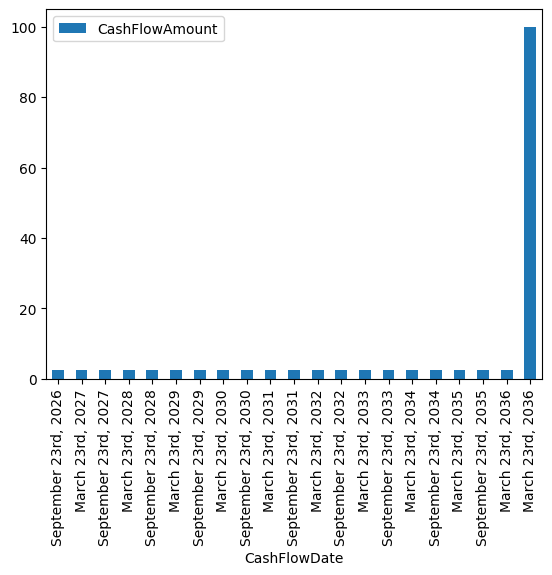

In [16]:
# Use the bond_details template below to quickly define the bond specs
test_bond_details = {'class': 'Corp',
                'start_date': '2026-03-23', 
                'acc_first': '2026-03-23', 
                'maturity': '2036-03-23', 
                'coupon': 5,
                'dcc' : '30/360',
                'days_settle' : 1}

# Use create_bond_from_symbology() to create the bond from the bond details dictionary
test_bond = create_bond_from_symbology(test_bond_details)
x = [(cf.date(), cf.amount()) for cf in test_bond.cashflows()]
cf_date_fixed, cf_amount = zip(*x)

# create and display cashflows dataframe
cf_frame_fixed = pd.DataFrame(data={'CashFlowDate': cf_date_fixed, 'CashFlowAmount': cf_amount})
print(cf_frame_fixed)

# plot cashflows
cf_frame_fixed.plot.bar(x='CashFlowDate', y='CashFlowAmount')

## b. Compute the bond price, DV01, duration and convexity (analytic method).

Assume that the market yield of the bond is 6%. Compute the bond price, DV01, duration and convexity, using the analytic method.

In [17]:
flat_rate = ql.SimpleQuote(0.05)
rate_handle = ql.QuoteHandle(flat_rate)
day_count = ql.Actual360()
continuous_comp = ql.Continuous
flat_yield_curve = ql.FlatForward(calc_date, rate_handle, day_count, continuous_comp)
flat_yield_curve_handle = ql.YieldTermStructureHandle(flat_yield_curve)

bond_engine = ql.DiscountingBondEngine(flat_yield_curve_handle)

test_bond.setPricingEngine(bond_engine)
    
day_count = ql.ActualActual(ql.ActualActual.ISMA)
compounding = ql.Compounded
frequency = ql.Semiannual

bond_rate = ql.InterestRate(test_bond.bondYield(day_count, compounding, frequency), day_count, compounding, frequency)
    
duration = ql.BondFunctions.duration(test_bond, bond_rate, ql.Duration.Modified)
convexity = ql.BondFunctions.convexity(test_bond, bond_rate)
dv01 = duration * test_bond.NPV() / 10000

print(f"Duration: {duration:.4f} years")
print(f"Convexity: {convexity:.4f}")
print(f"DV01: {dv01:.4f}")

Duration: 7.7740 years
Convexity: 73.3302
DV01: 0.0769


## c. Scenario bond prices: "re-pricing" vs "second-order approximations"

Compute the scenario bond prices on the following scenario yield grid: [from 1% to 11% in steps of 0.5%]

Compute the second-order scenario price approximations using duration and convexity sensitivities (formula 13 from Lecture 1).

\begin{align}
\Delta B(y) = B\left(y+\Delta y\right)-B\left(y\right)\approx B\cdot\left[- D\cdot\Delta y+\frac{1}{2}\cdot\Gamma\cdot\left(\Delta y\right)^{2}\right]
\end{align}

Plot the scenario prices (Y-axis) vs yieds (X-axis), for both the "re-pricing" and "second-order approximations" method.

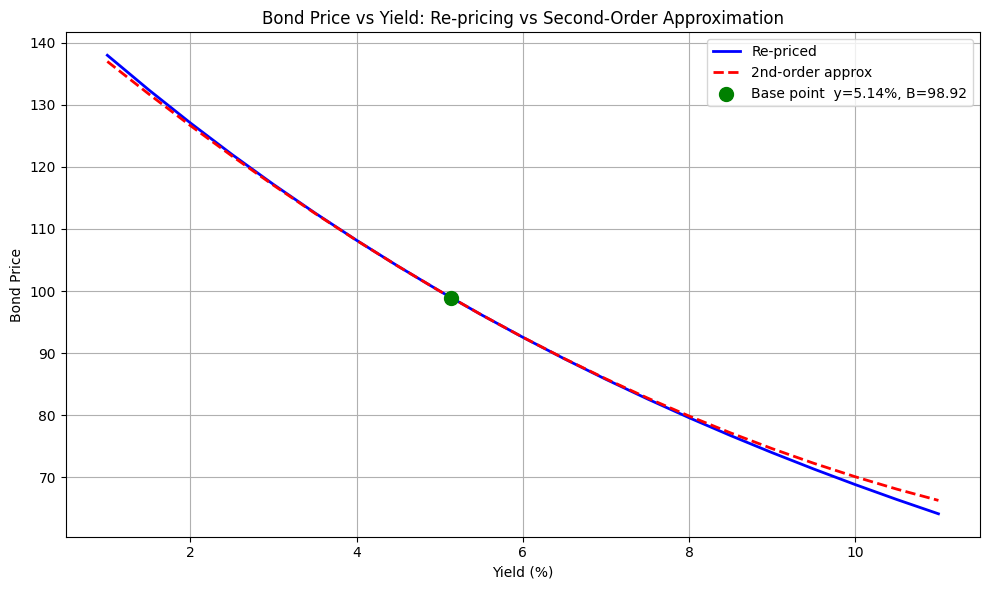

In [18]:
import numpy as np
import matplotlib.pyplot as plt


y0 = test_bond.bondYield(day_count, compounding, frequency)
B0 = test_bond.NPV()   


yield_grid = np.arange(0.01, 0.115, 0.005)


repriced_prices = [
    test_bond.cleanPrice(y, day_count, compounding, frequency)
    for y in yield_grid
]


approx_prices = [
    B0 + B0 * (-duration * (y - y0) + 0.5 * convexity * (y - y0)**2)
    for y in yield_grid
]


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yield_grid * 100, repriced_prices, 'b-',  label='Re-priced',            linewidth=2)
ax.plot(yield_grid * 100, approx_prices,   'r--', label='2nd-order approx',     linewidth=2)
ax.scatter([y0 * 100], [B0], color='green', s=100, zorder=5,
           label=f'Base point  y={y0:.2%}, B={B0:.2f}')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Bond Price')
ax.set_title('Bond Price vs Yield: Re-pricing vs Second-Order Approximation')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## d. Extreme event scenarios

Compute and show the scenario bond price for a bond yield of 15% (extreme event scenario).

Compute and show the second-order scenario price approximation in the extreme event scenario.

Compute and show the analytic DV01, duration and convexity in the extreme event scenario.

How accurate is the second-order approximation (Taylor expansion using duration and convexity) in the extreme event case, and why?

In [32]:
y_extreme = 0.15


B_extreme = test_bond.cleanPrice(y_extreme, day_count, compounding, frequency)
print(f'Re-priced bond price at y=15%: {B_extreme:.4f}')


dy_extreme = y_extreme - y0
B_approx_extreme = B0 + B0 * (-duration * dy_extreme + 0.5 * convexity * dy_extreme**2)
print(f'2nd-order approx bond price at y=15%: {B_approx_extreme:.4f}')
print(f'Approximation error: {B_approx_extreme - B_extreme:.4f}')
print(f'Relative error: {(B_approx_extreme - B_extreme)/B_extreme:.2%}')


bond_rate_extreme = ql.InterestRate(y_extreme, day_count, compounding, frequency)
duration_extreme  = ql.BondFunctions.duration(test_bond, bond_rate_extreme, ql.Duration.Modified)
convexity_extreme = ql.BondFunctions.convexity(test_bond, bond_rate_extreme)
dv01_extreme      = duration_extreme * B_extreme / 10000

print(f'Modified Duration : {duration_extreme:.4f} years')
print(f'Convexity : {convexity_extreme:.4f}')
print(f'DV01: {dv01_extreme:.6f}')

Re-priced bond price at y=15%: 49.0329
2nd-order approx bond price at y=15%: 58.3585
Approximation error: 9.3256
Relative error: 19.02%
Modified Duration : 6.4408 years
Convexity : 55.4072
DV01: 0.031581


The second-order Taylor expansion becomes materially less accurate for large
yield moves (here Δy ≈ 10%) because:
  1. Higher-order terms in the Taylor series are ignored.
  2. The bond price–yield relationship is a convex, globally curved function;
     the second-order parabola is only a local approximation around y0.
  3. Consequently, the approximation overestimates the bond price at y = 15%

-----------------------------------------------------------
# Problem 4: Perpetual bonds
## a. Price a fixed rate perpetual bond
We are interested in a fixed rate perpetual bond (infinite maturity) on a face notional of $100 and semi-annual coupon c.

Assuming that the bond has a known continuously componded yield of y, what is the price of the perpetual bond (assume T+0 settlement and zero accrued)?

Use the definition of the semi-annual yield: $y_{sa} = 2 \cdot \left(e^{\frac{y}{2}}-1 \right)$.

You can use following sympy code (implementing Formula 5 from Session 1) as a starting point.

In [28]:
# import libraries
import sympy as sp

# define fixed rate bond specs as symbolic variables
T = sp.symbols('T', positive=True)
c = sp.symbols('c', positive=True)
y = sp.symbols('y', positive=True)

# define symbolic equation for generic fixed rate bond pv (Formula 5 from Session 1)
bond_pv_eq = 1 + (c/2 / (sp.exp(y/2) - 1) - 1) * (1 - sp.exp(-T*y))
print('Bond PV formula (finite maturity):')
display(bond_pv_eq)


perp_pv = sp.limit(bond_pv_eq, T, sp.oo)
perp_pv = sp.simplify(perp_pv)
print('\nPerpetual bond PV (limit T -> inf):')
display(perp_pv)


Bond PV formula (finite maturity):


(1 - exp(-T*y))*(c/(2*(exp(y/2) - 1)) - 1) + 1


Perpetual bond PV (limit T -> inf):


c/(2*exp(y/2) - 2)

## b. Perpetual bonds priced "at par"
For which yield y does the bond trade "at par", i.e. fair value price = $100?

In [22]:
# At par means B_perp = 1 (per unit of $100 face, i.e. normalised)
# Solve:  c/2 / (exp(y/2) - 1) = 1
par_eq = sp.Eq(perp_pv, 1)
par_yield_solution = sp.solve(par_eq, y)

print('At-par condition: B_perp = 1')
print('Solution for y (continuously compounded):')
for sol in par_yield_solution:
    display(sol)

At-par condition: B_perp = 1
Solution for y (continuously compounded):


2*log(c/2 + 1)

## c. Duration and DV01 for a fixed rate perpetual bond

Compute Duration and DV01 of the perpetual bond.

Use the simpy.diff() function to compute function derivatives.

In [27]:
# Duration:  D = -(1/B) * dB/dy
dB_dy  = sp.diff(perp_pv, y)
D_perp = sp.simplify(-dB_dy / perp_pv)
print('Macaulay Duration of perpetual bond:')
display(D_perp)


DV01_perp = sp.simplify(D_perp * perp_pv * sp.Integer(100) / 10000)
print('\nDV01 per $100 face notional:')
display(DV01_perp)

Macaulay Duration of perpetual bond:


exp(y/2)/(2*exp(y/2) - 2)


DV01 per $100 face notional:


c/(1600*sinh(y/4)**2)

## d. Convexity of a fixed rate perpetual bond
Compute the convexity of the perpetual bond.

In [26]:
d2B_dy2    = sp.diff(perp_pv, y, 2)
Gamma_perp = sp.simplify(d2B_dy2 / perp_pv)
print('Convexity of perpetual bond:')
display(Gamma_perp)

Convexity of perpetual bond:


(1 + exp(-y/2))*exp(y)/(4*(-2*exp(y/2) + exp(y) + 1))